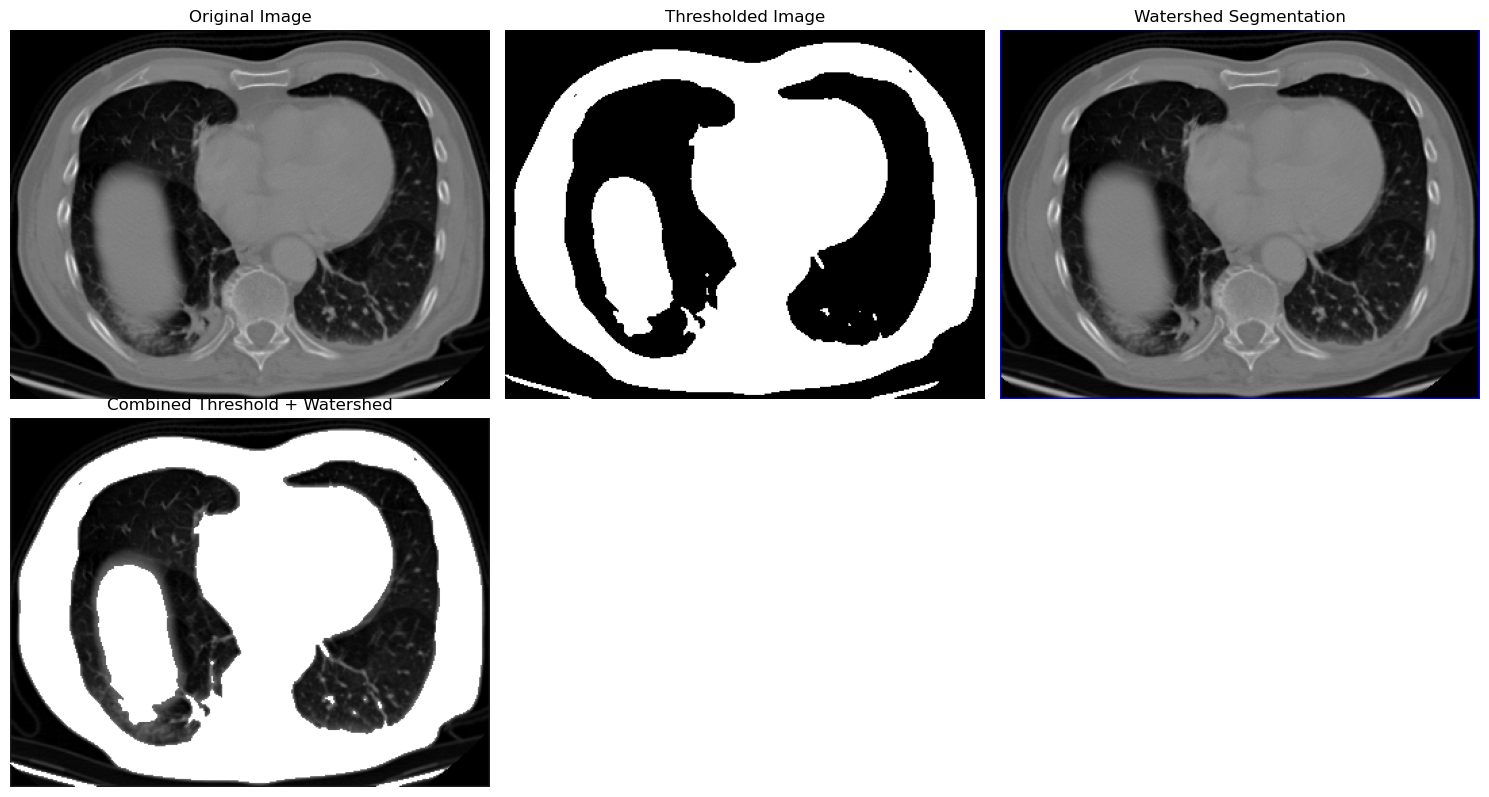

Thresholding and Watershed segmentation completed. Check the output image.


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_lung_cancer_and_segment(image_path, threshold_value):
    # Read the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was loaded
    if image is None:
        print("Error: Could not load image.")
        return

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Thresholding: Convert to binary image
    _, thresholded = cv2.threshold(blurred, threshold_value, 255, cv2.THRESH_BINARY)

    # Convert the image to color for watershed segmentation (needed for watershed)
    color_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Dilate the thresholded image to close gaps in the regions
    dilated_threshold = cv2.dilate(thresholded, None, iterations=2)

    # Find contours in the dilated thresholded image
    contours, _ = cv2.findContours(dilated_threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a mask for the sure foreground area
    mask = np.zeros(image.shape, dtype=np.uint8)

    # Fill the contours on the mask
    for contour in contours:
        cv2.drawContours(mask, [contour], -1, 255, -1)

    # Perform distance transform
    dist_transform = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

    # Find unknown region (background)
    unknown = cv2.subtract(mask, sure_fg.astype(np.uint8))

    # Label markers for watershed
    markers = np.zeros_like(image, dtype=np.int32)
    markers[sure_fg.astype(np.uint8) == 255] = 1
    markers[unknown == 255] = 2

    # Apply the Watershed algorithm
    cv2.watershed(color_image, markers)

    # Mark the boundaries on the original image (red)
    color_image[markers == -1] = [255, 0, 0]  # Mark edges in red

    # Display the results in one figure
    plt.figure(figsize=(15, 8))

    # Original Image
    plt.subplot(2, 3, 1)
    plt.title('Original Image')
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    # Thresholded Image
    plt.subplot(2, 3, 2)
    plt.title('Thresholded Image')
    plt.imshow(thresholded, cmap='gray')
    plt.axis('off')

    # Watershed Segmentation
    plt.subplot(2, 3, 3)
    plt.title('Watershed Segmentation')
    plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Combined result (Thresholded + Watershed Boundaries)
    combined_result = cv2.bitwise_or(thresholded, cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY))
    plt.subplot(2, 3, 4)
    plt.title('Combined Threshold + Watershed')
    plt.imshow(combined_result, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Save the result (optional)
    output_path = 'combined_output.png'  # Path to save the combined output image
    cv2.imwrite(output_path, color_image)

    print("Thresholding and Watershed segmentation completed. Check the output image.")

# Example usage
image_path = '000122.png'  # Change to your image path
threshold_value = 100  # Adjust this value based on your image
detect_lung_cancer_and_segment(image_path, threshold_value)
